# **Part 2: Exploratory Analysis and Loan Seasoning**

Looks at how default rates vary across borrower and loan characteristics, then measures how long a loan typically takes to charge off and what that means for the loans still active today.

**Input:** model_df_cleaned.csv

In [1]:
# All libraries used in this notebook, collected here so it runs cleanly from top to bottom
import os

import pandas as pd                  # loading and grouping the loan data
import numpy as np                   # numeric operations
import matplotlib.pyplot as plt      # bar charts, histograms and line charts
import plotly.express as px          # the state choropleth map
import plotly.graph_objects as go    # text labels layered onto the map

# Charts are written here as they're produced
os.makedirs('figures', exist_ok=True)

In [2]:
import pandas as pd

model_df = pd.read_csv("Model df cleaned.csv")  #importing the cleaned dataset

model_df.shape    # confirming it matches with the cleaned model data that we file we made in part 1 for further analysis. should be (74976, 46)

(74976, 46)

## **Stage 3: Exploring the Data**

**Default rate by industry**

Checking the count behind each sector's rate alongside the rate itself, since a percentage from a handful of loans isn't trustworthy whichever way it points. Sectors with too few loans get filtered out before drawing any conclusion from the table.


In [3]:

# Averaging a 0/1 column within each group gives the default rate for that group
sector_default_rate = model_df.groupby('NaicsSector').agg(
    default_rate=('default', 'mean'),
    sector_name=('NaicsDescription', 'first')
).sort_values('default_rate', ascending=False)

sector_default_rate  # highest-risk sectors at the top




,default_rate,sector_name
NaicsSector,,
48,0.156250,"General Freight Trucking, Long-Distance, Truck..."
49,0.137079,Local Messengers and Local Delivery
45,0.134120,Electronic Shopping
22,0.109489,Water Supply and Irrigation Systems
42,0.106429,Other Miscellaneous Nondurable Goods Merchant ...
71,0.104328,All Other Amusement and Recreation Industries
61,0.103125,All Other Miscellaneous Schools and Instruction
51,0.100000,Record Production and Distribution
54,0.097982,Veterinary Services


In [4]:
# Checking sample size behind each sector's default rate

sector_default_rate = model_df.groupby('NaicsSector').agg(
    default_rate=('default', 'mean'),  
    loan_count=('default', 'count'),                   # Here i have also added the loan count in previous code 
    sector_name=('NaicsDescription', 'first')
).sort_values('default_rate', ascending=False)

# To get value in percentage
sector_default_rate['default_rate'] = (sector_default_rate['default_rate'] * 100).round(2) 

sector_default_rate

,default_rate,loan_count,sector_name
NaicsSector,,,
48,15.62,5312,"General Freight Trucking, Long-Distance, Truck..."
49,13.71,445,Local Messengers and Local Delivery
45,13.41,3303,Electronic Shopping
22,10.95,137,Water Supply and Irrigation Systems
42,10.64,3702,Other Miscellaneous Nondurable Goods Merchant ...
71,10.43,2195,All Other Amusement and Recreation Industries
61,10.31,960,All Other Miscellaneous Schools and Instruction
51,10.00,700,Record Production and Distribution
54,9.80,6889,Veterinary Services


In [5]:
# Keeping only sectors backed by at least 100 loans, since smaller samples give unreliable default rates
reliable_sectors = sector_default_rate[sector_default_rate['loan_count'] >= 100]

reliable_sectors

,default_rate,loan_count,sector_name
NaicsSector,,,
48,15.62,5312,"General Freight Trucking, Long-Distance, Truck..."
49,13.71,445,Local Messengers and Local Delivery
45,13.41,3303,Electronic Shopping
22,10.95,137,Water Supply and Irrigation Systems
42,10.64,3702,Other Miscellaneous Nondurable Goods Merchant ...
71,10.43,2195,All Other Amusement and Recreation Industries
61,10.31,960,All Other Miscellaneous Schools and Instruction
51,10.00,700,Record Production and Distribution
54,9.80,6889,Veterinary Services


In [6]:
# Building a report-ready table with sector code as index and clean column names
report_table = reliable_sectors[['sector_name', 'default_rate', 'loan_count']]
report_table.columns = ['Industry Sector', 'Default Rate (%)', 'Loan Count']

report_table

,Industry Sector,Default Rate (%),Loan Count
NaicsSector,,,
48,"General Freight Trucking, Long-Distance, Truck...",15.62,5312
49,Local Messengers and Local Delivery,13.71,445
45,Electronic Shopping,13.41,3303
22,Water Supply and Irrigation Systems,10.95,137
42,Other Miscellaneous Nondurable Goods Merchant ...,10.64,3702
71,All Other Amusement and Recreation Industries,10.43,2195
61,All Other Miscellaneous Schools and Instruction,10.31,960
51,Record Production and Distribution,10.00,700
54,Veterinary Services,9.80,6889


**Default rate by business age**

Checking whether how established a business is at the time of the loan relates to whether it defaults.

In [7]:
# Default rate and sample size by business age category, sorted highest risk first
business_age_default = model_df.groupby('BusinessAge').agg(
    default_rate=('default', 'mean'),
    loan_count=('default', 'count')
).sort_values('default_rate', ascending=False)

business_age_default['default_rate'] = (business_age_default['default_rate'] * 100).round(2)

business_age_default

,default_rate,loan_count
BusinessAge,,
New Business or 2 years or less,13.75,12723
"Startup, Loan Funds will Open Business",9.48,11455
Existing or more than 2 years old,8.54,40843
Unanswered,6.72,2472
Change of Ownership,4.52,7483


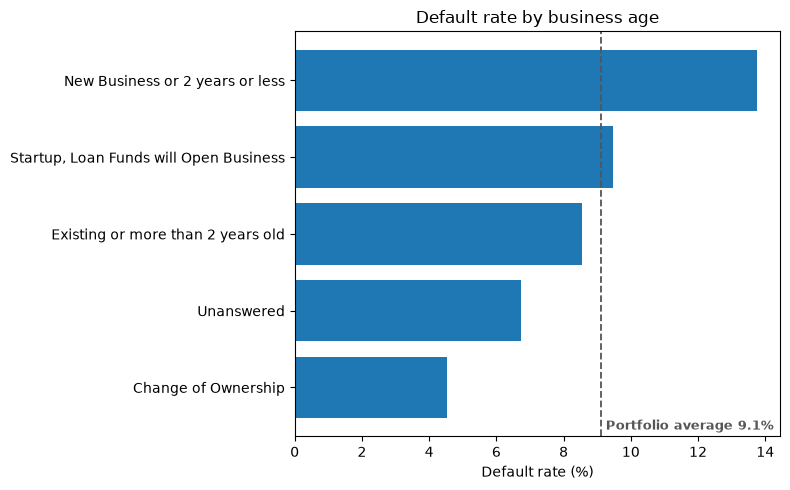

In [51]:
import os

# Making a figures folder to store all the charts from this project
os.makedirs('figures', exist_ok=True)

import matplotlib.pyplot as plt

overall_rate = model_df['default'].mean() * 100

# Drawing a horizontal bar for each business age category, using its default rate
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(business_age_default.index, business_age_default['default_rate'])

ax.invert_yaxis()  # putting the highest default rate at the top instead of the bottom
ax.set_xlabel('Default rate (%)')
ax.set_title('Default rate by business age')
plt.tight_layout()  # preventing labels from getting cut off at the edges


ax.axvline(overall_rate, color='#555555', linestyle='--', linewidth=1.3)
ax.text(overall_rate + 0.15, len(business_age_default) - 0.45, f'Portfolio average {overall_rate:.1f}%',
        fontsize=9, color='#555555', fontweight='bold')

plt.savefig('figures/nb02_fig01_default_rate_by_business_age.png', dpi=150)  # saving with notebook + figure number
plt.show()  # displaying the chart here in the notebook

**Default rate by loan size**

Grouping loans into size bands and checking the default rate in each.

In [11]:
# Grouping loans into size bands, then checking default rate and count within each band
model_df['LoanSizeBand'] = pd.cut(
    model_df['GrossApproval'],
    bins=[0, 50000, 150000, 350000, 1000000, float('inf')],
    labels=['Under $50k', '$50k-$150k', '$150k-$350k', '$350k-$1M', 'Over $1M']
)

loan_size_default = model_df.groupby('LoanSizeBand', observed=True).agg(
    default_rate=('default', 'mean'),
    loan_count=('default', 'count')
).sort_values('default_rate', ascending=False)

loan_size_default['default_rate'] = (loan_size_default['default_rate'] * 100).round(2)

loan_size_default

,default_rate,loan_count
LoanSizeBand,,
Under $50k,15.33,21763
$50k-$150k,12.44,16256
$150k-$350k,6.76,13445
$350k-$1M,3.03,13009
Over $1M,1.56,10503


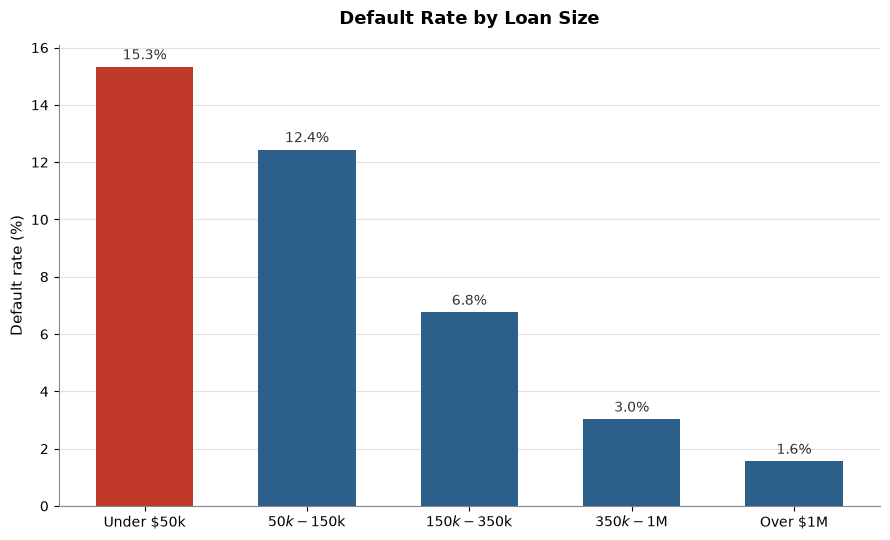

In [40]:
loan_size_ordered = loan_size_default.reindex(['Under $50k', '$50k-$150k', '$150k-$350k', '$350k-$1M', 'Over $1M'])

fig, ax = plt.subplots(figsize=(9, 5.5))

# Flagging the highest-risk band so the chart highlights the finding, not just the data
highest_band = loan_size_ordered['default_rate'].idxmax()
colors = ['#c0392b' if band == highest_band else '#2c5f8a' for band in loan_size_ordered.index]

bars = ax.bar(loan_size_ordered.index, loan_size_ordered['default_rate'], color=colors, width=0.6, zorder=3)

# Printing the rate on top of each bar so readers don't have to cross-reference the axis
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10, color='#333333')

# Adding a light horizontal grid for scale, placed behind the bars
ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# Removing the top and right frame lines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')

ax.set_ylabel('Default rate (%)', fontsize=11)
ax.set_title('Default Rate by Loan Size', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.savefig('figures/nb02_fig02_default_rate_by_loan_size.png', dpi=150, bbox_inches='tight')
plt.show()

**Default rate by state**

Same check by borrower location, with the same sample-size filtering applied since some states have very few loans.

In [13]:
# Checking default rate and sample size by state, sorted highest risk first
state_default = model_df.groupby('BorrState').agg(
    default_rate=('default', 'mean'),
    loan_count=('default', 'count')
).sort_values('default_rate', ascending=False)

state_default['default_rate'] = (state_default['default_rate'] * 100).round(2)  # converting to percentage for readability

state_default


,default_rate,loan_count
BorrState,,
DC,26.72,131
NY,19.94,4047
DE,17.32,231
NJ,16.27,2212
FL,14.86,4813
MD,14.66,1112
NV,13.43,752
LA,12.64,451
HI,11.71,205


In [14]:
# Keeping only states with a large enough loan count for the default rate to be trustworthy
reliable_states = state_default[state_default['loan_count'] >= 100]

reliable_states

,default_rate,loan_count
BorrState,,
DC,26.72,131
NY,19.94,4047
DE,17.32,231
NJ,16.27,2212
FL,14.86,4813
MD,14.66,1112
NV,13.43,752
LA,12.64,451
HI,11.71,205


In [15]:
# Mapping state abbreviations to full names for readability as the data only contain abbreviations not names of the states
state_names = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'DC': 'District of Columbia',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois',
    'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana',
    'ME': 'Maine', 'MD': 'Maryland', 'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota',
    'MS': 'Mississippi', 'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon',
    'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina', 'SD': 'South Dakota',
    'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont', 'VA': 'Virginia',
    'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'PR': 'Puerto Rico', 'VI': 'U.S. Virgin Islands', 'GU': 'Guam'
}

# Attaching the full state name as a new column, using the mapping above
reliable_states = reliable_states.copy()
reliable_states['state_name'] = reliable_states.index.map(state_names)

reliable_states

,default_rate,loan_count,state_name
BorrState,,,
DC,26.72,131,District of Columbia
NY,19.94,4047,New York
DE,17.32,231,Delaware
NJ,16.27,2212,New Jersey
FL,14.86,4813,Florida
MD,14.66,1112,Maryland
NV,13.43,752,Nevada
LA,12.64,451,Louisiana
HI,11.71,205,Hawaii


In [62]:
import plotly.express as px
import plotly.graph_objects as go

state_coords = {
    'AL': (32.318231, -86.902298), 'AK': (63.588753, -154.493062), 'AZ': (34.048928, -111.093731),
    'AR': (35.20105, -91.831833), 'CA': (36.778261, -119.417932), 'CO': (39.550051, -105.782067),
    'CT': (41.603221, -73.087749), 'DE': (38.910832, -75.52767), 'DC': (38.905985, -77.033418),
    'FL': (27.664827, -81.515754), 'GA': (32.157435, -82.907123), 'HI': (19.898682, -155.665857),
    'ID': (44.068202, -114.742041), 'IL': (40.633125, -89.398528), 'IN': (40.551217, -85.602364),
    'IA': (41.878003, -93.097702), 'KS': (39.011902, -98.484246), 'KY': (37.839333, -84.270018),
    'LA': (30.984298, -91.962333), 'ME': (45.253783, -69.445469), 'MD': (39.045755, -76.641271),
    'MA': (42.407211, -71.382437), 'MI': (44.314844, -85.602364), 'MN': (46.729553, -94.6859),
    'MS': (32.354668, -89.398528), 'MO': (37.964253, -91.831833), 'MT': (46.879682, -110.362566),
    'NE': (41.492537, -99.901813), 'NV': (38.80261, -116.419389), 'NH': (43.193852, -71.572395),
    'NJ': (40.058324, -74.405661), 'NM': (34.97273, -105.032363), 'NY': (43.299428, -74.217933),
    'NC': (35.759573, -79.0193), 'ND': (47.551493, -101.002012), 'OH': (40.417287, -82.907123),
    'OK': (35.007752, -97.092877), 'OR': (43.804133, -120.554201), 'PA': (41.203322, -77.194525),
    'RI': (41.580095, -71.477429), 'SC': (33.836081, -81.163725), 'SD': (43.969515, -99.901813),
    'TN': (35.517491, -86.580447), 'TX': (31.968599, -99.901813), 'UT': (39.32098, -111.093731),
    'VT': (44.558803, -72.577841), 'VA': (37.431573, -78.656894), 'WA': (47.751074, -120.740139),
    'WV': (38.597626, -80.454903), 'WI': (43.784, -88.787868), 'WY': (43.075968, -107.290284),
    'PR': (18.220833, -66.590149)
}

reliable_states_reset = reliable_states.reset_index()
reliable_states_reset['lat'] = reliable_states_reset['BorrState'].map(lambda s: state_coords.get(s, (None, None))[0])
reliable_states_reset['lon'] = reliable_states_reset['BorrState'].map(lambda s: state_coords.get(s, (None, None))[1])

fig = px.choropleth(
    reliable_states_reset,
    locations='BorrState',
    locationmode='USA-states',
    color='default_rate',
    scope='usa',
    color_continuous_scale='Reds',
    labels={'default_rate': 'Default Rate (%)'},
    title='Default Rate by State'
)

# Coloring state borders white so adjacent states stay visually separated
fig.update_traces(marker_line_color='white', marker_line_width=0.6, selector=dict(type='choropleth'))

# Switching label color per state so text stays legible on both dark and light fills
midpoint = reliable_states_reset['default_rate'].quantile(0.6)
text_colors = ['white' if r >= midpoint else '#333333' for r in reliable_states_reset['default_rate']]

fig.add_trace(go.Scattergeo(
    lat=reliable_states_reset['lat'],
    lon=reliable_states_reset['lon'],
    text=reliable_states_reset['BorrState'],
    mode='text',
    textfont=dict(size=9, color=text_colors),
    showlegend=False
))

# Centering the title and tightening the margins plotly adds by default
fig.update_layout(
    title=dict(font=dict(size=17, color='#333333'), x=0.5, xanchor='center'),
    margin=dict(l=10, r=10, t=60, b=10),
    coloraxis_colorbar=dict(len=0.7)
)
fig.update_geos(bgcolor='white', lakecolor='white', showlakes=False)

fig.write_image('figures/nb02_fig03_default_rate_by_state.png', width=1200, height=700, scale=2)
fig.show()

**Default rate by lender**

Checking whether the lender itself relates to default rate. Over 1,600 individual lenders means most have too few loans to say anything reliable alone, so small ones get grouped together first.

In [17]:
# Checking default rate and sample size by lender, sorted highest risk first
lender_default = model_df.groupby('BankName').agg(
    default_rate=('default', 'mean'),
    loan_count=('default', 'count')
).sort_values('default_rate', ascending=False)

lender_default['default_rate'] = (lender_default['default_rate'] * 100).round(2)

lender_default

,default_rate,loan_count
BankName,,
Embold Federal Credit Union,100.0,1
Farmers & Merchants Bank of North Dakota,100.0,1
Centric Federal Credit Union,100.0,2
Certified Development Corporation of South Carolina,100.0,1
DeMotte State Bank,100.0,1
...,...,...
Wyoming Capital Access,0.0,1
Wright Patt Credit Union Inc,0.0,7
1st Security Bank of Washington,0.0,27


In [18]:
# Checking how many lenders survive at different sample-size thresholds
for threshold in [10, 30, 50, 100]:
    surviving = (lender_default['loan_count'] >= threshold).sum()
    print(f"Lenders with at least {threshold} loans: {surviving}")

Lenders with at least 10 loans: 667
Lenders with at least 30 loans: 314
Lenders with at least 50 loans: 224
Lenders with at least 100 loans: 111


In [19]:
# Keeping only lenders with a large enough loan count for the default rate to be trustworthy
reliable_lenders = lender_default[lender_default['loan_count'] >= 50]

reliable_lenders

,default_rate,loan_count
BankName,,
CDC Small Business Finance Corp.,40.67,359
"TD Bank, National Association",32.19,3187
BayFirst National Bank,29.57,1197
United Midwest Savings Bank National Association,26.00,1046
Wells Fargo Bank National Association,24.58,2453
...,...,...
Ultima Bank Minnesota,0.00,81
United Prairie Bank,0.00,56
Valley National Bank,0.00,61


In [20]:
# Combining the 10 highest-risk and 10 lowest-risk reliable lenders into one view
top_bottom_lenders = pd.concat([
    reliable_lenders.head(10),
    reliable_lenders.tail(10)
])

top_bottom_lenders

,default_rate,loan_count
BankName,,
CDC Small Business Finance Corp.,40.67,359
"TD Bank, National Association",32.19,3187
BayFirst National Bank,29.57,1197
United Midwest Savings Bank National Association,26.00,1046
Wells Fargo Bank National Association,24.58,2453
Manufacturers and Traders Trust Company,23.51,2680
Trustmark Bank,23.08,65
The Central Trust Bank,20.27,74
"PNC Bank, National Association",19.57,792


**The rate environment, measured in this data**

The research question concerns lending in a higher-rate environment, so it's worth establishing that shift from this file directly. Interest rate is fixed at approval and applies to every loan regardless of outcome, so this is computed on the full file rather than the modelled population.

In [21]:
# Loading the original full dataset, since interest rate applies to every loan regardless of outcome
df = pd.read_csv('FOIA_7a_FY2020_Present_asof_260630.csv')

# Mean initial interest rate by approval fiscal year, across all loans in the file
rate_by_year = df.groupby('ApprovalFY').agg(
    mean_rate=('InitialInterestRate', 'mean'),
    median_rate=('InitialInterestRate', 'median'),
    loan_count=('InitialInterestRate', 'count')
).round(2)

rate_by_year

C:\Users\Muhammad Mubashar\AppData\Local\Temp\ipykernel_10344\1886279350.py:2: DtypeWarning: Columns (0: ChargeOffDate) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('FOIA_7a_FY2020_Present_asof_260630.csv')


,mean_rate,median_rate,loan_count
ApprovalFY,,,
2020,6.46,6.00,42298
2021,5.50,5.50,51856
2022,6.43,6.00,47678
2023,10.13,10.25,57362
2024,11.13,11.25,70241
2025,10.32,10.25,78073
2026,9.55,9.50,40822


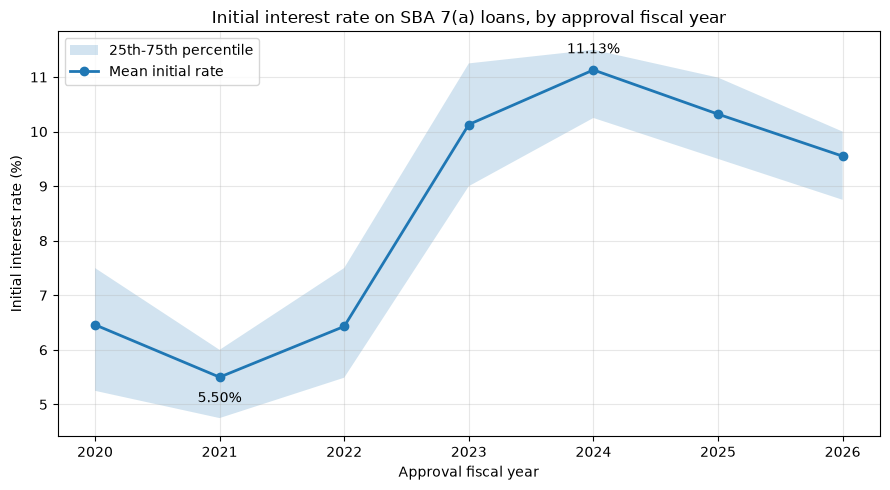

In [22]:
# Mean rate plus quartiles by fiscal year, so the chart can show spread as well as the average
rate_by_year_full = df.groupby('ApprovalFY').agg(
    mean_rate=('InitialInterestRate', 'mean'),
    q25=('InitialInterestRate', lambda x: x.quantile(0.25)),
    q75=('InitialInterestRate', lambda x: x.quantile(0.75)),
    loan_count=('InitialInterestRate', 'count')
).round(2)

fig, ax = plt.subplots(figsize=(9, 5))

# Shading the interquartile range behind the mean line
ax.fill_between(rate_by_year_full.index, rate_by_year_full['q25'], rate_by_year_full['q75'], alpha=0.2, label='25th-75th percentile')
ax.plot(rate_by_year_full.index, rate_by_year_full['mean_rate'], marker='o', linewidth=2, label='Mean initial rate')

# Finding the lowest and highest years, then labelling those two points
trough_year = rate_by_year_full['mean_rate'].idxmin()
peak_year = rate_by_year_full['mean_rate'].idxmax()
trough_rate = rate_by_year_full.loc[trough_year, 'mean_rate']
peak_rate = rate_by_year_full.loc[peak_year, 'mean_rate']

ax.annotate(f"{trough_rate:.2f}%", (trough_year, trough_rate), textcoords="offset points", xytext=(0, -18), ha='center')
ax.annotate(f"{peak_rate:.2f}%", (peak_year, peak_rate), textcoords="offset points", xytext=(0, 12), ha='center')

ax.set_xlabel('Approval fiscal year')
ax.set_ylabel('Initial interest rate (%)')
ax.set_title('Initial interest rate on SBA 7(a) loans, by approval fiscal year')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('figures/nb02_fig05_interest_rate_by_fiscal_year.png', dpi=300, bbox_inches='tight')
plt.show()

## **Stage 4: Loan Seasoning**

A loan can only show up as charged off once it has actually failed, and failure takes time. This checks how long that typically takes, and what it means for loans still active today.

In [23]:
# Checking how long it typically takes a loan to go from approval to charge-off

# Converting both dates to real date type, ApprovalDate went back to text after we reloaded the CSV
model_df['ApprovalDate'] = pd.to_datetime(model_df['ApprovalDate'])
model_df['ChargeOffDate'] = pd.to_datetime(model_df['ChargeOffDate'])

# Only loans that actually charged off have a ChargeOffDate, so I'm filtering to just those
chgoff_only = model_df[model_df['default'] == 1].copy()

# Working out how many months passed between approval and charge-off
chgoff_only['MonthsToChargeOff'] = (chgoff_only['ChargeOffDate'] - chgoff_only['ApprovalDate']).dt.days / 30.44        # Here i used 30.44 as an average/standardized month days of year 

chgoff_only['MonthsToChargeOff'].describe()

count    6821.000000
mean       37.293039
std        15.049570
min         5.946124
25%        25.788436
50%        35.446781
75%        46.846255
max        80.847569
Name: MonthsToChargeOff, dtype: float64

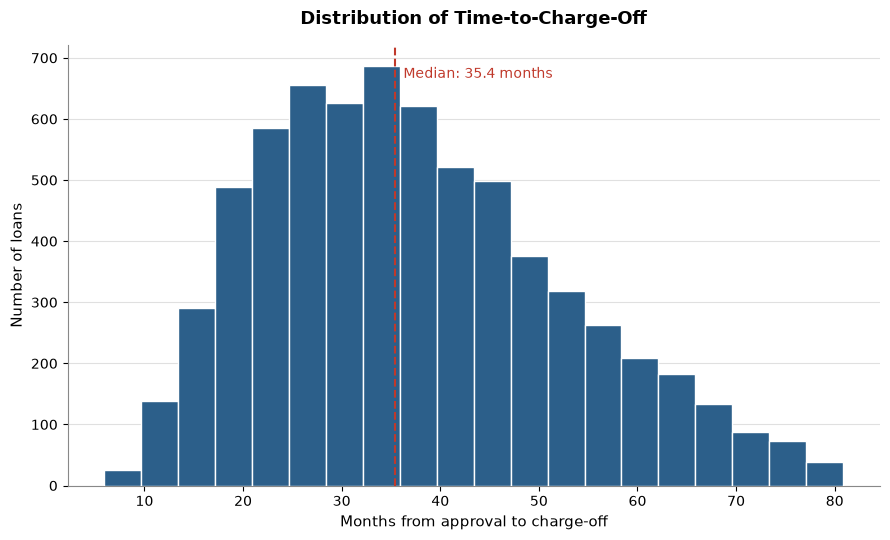

In [54]:
fig, ax = plt.subplots(figsize=(9, 5.5))

# Coloring bars to match the loan-size chart, keeping the report's palette consistent
ax.hist(chgoff_only['MonthsToChargeOff'], bins=20, color='#2c5f8a', edgecolor='white', zorder=3)

# Marking the median, since charge-off timing is usually right-skewed and the mean would overstate the typical case
median_months = chgoff_only['MonthsToChargeOff'].median()
ax.axvline(median_months, color='#c0392b', linestyle='--', linewidth=1.5, zorder=4)
ax.text(median_months, ax.get_ylim()[1] * 0.95, f'  Median: {median_months:.1f} months', color='#c0392b', fontsize=10, va='top')

ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')

ax.set_xlabel('Months from approval to charge-off', fontsize=11)
ax.set_ylabel('Number of loans', fontsize=11)
ax.set_title('Distribution of Time-to-Charge-Off', fontsize=13, fontweight='bold', pad=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.savefig('figures/nb02_fig04_months_to_chargeoff.png', dpi=150, bbox_inches='tight')
plt.show()

**The current book, checked against that timeline**

Using the typical time-to-charge-off just found, checking how many of today's active loans haven't been open long enough for a default to have had a chance to show up.

In [25]:

df = pd.read_csv('FOIA_7a_FY2020_Present_asof_260630.csv')

# Converting ApprovalDate to a real date, same as before
df['ApprovalDate'] = pd.to_datetime(df['ApprovalDate'])

# Working out how many months have passed since approval, measured against the data's snapshot date
snapshot_date = pd.to_datetime('2026-06-30')
df['MonthsSinceApproval'] = (snapshot_date - df['ApprovalDate']).dt.days / 30.44

# Checking what share of currently active loans are under 36 months old, the seasoning threshold
# found in the previous step, since most loans take 25+ months to reveal a charge-off
exempt_loans = df[df['LoanStatus'] == 'EXEMPT']
under_seasoned = (exempt_loans['MonthsSinceApproval'] < 36).sum()
total_exempt = len(exempt_loans)

print(f"Under-seasoned EXEMPT loans: {under_seasoned} out of {total_exempt} ({under_seasoned / total_exempt * 100:.1f}%)")

C:\Users\Muhammad Mubashar\AppData\Local\Temp\ipykernel_10344\140840459.py:1: DtypeWarning: Columns (0: ChargeOffDate) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('FOIA_7a_FY2020_Present_asof_260630.csv')


Under-seasoned EXEMPT loans: 147242 out of 242061 (60.8%)
